In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Matplotlib is building the font cache; this may take a moment.


In [5]:
df = pd.read_csv(r"C:\Users\Sanjana\OneDrive\Desktop\studentperf\data\Student_Performance.csv")
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [6]:
df.shape

(10000, 6)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [8]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [9]:
df.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

In [10]:
df.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [11]:
df['Extracurricular Activities'].unique()

array(['Yes', 'No'], dtype=object)

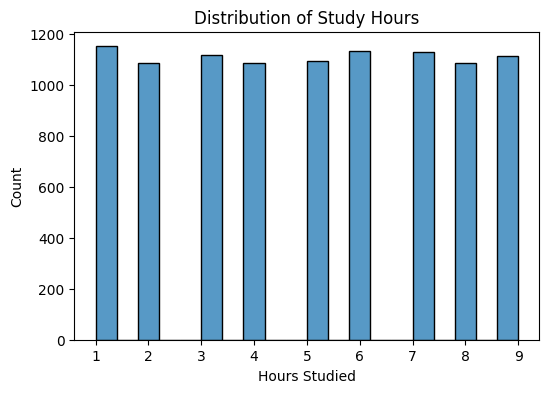

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['Hours Studied'], bins=20)
plt.title("Distribution of Study Hours")
plt.show()

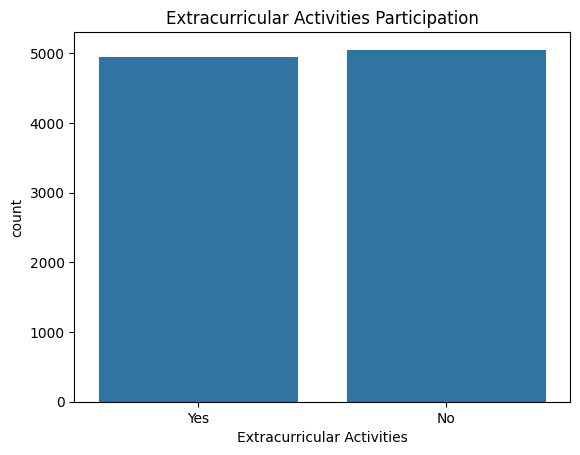

In [13]:
sns.countplot(x='Extracurricular Activities', data=df)
plt.title("Extracurricular Activities Participation")
plt.show()

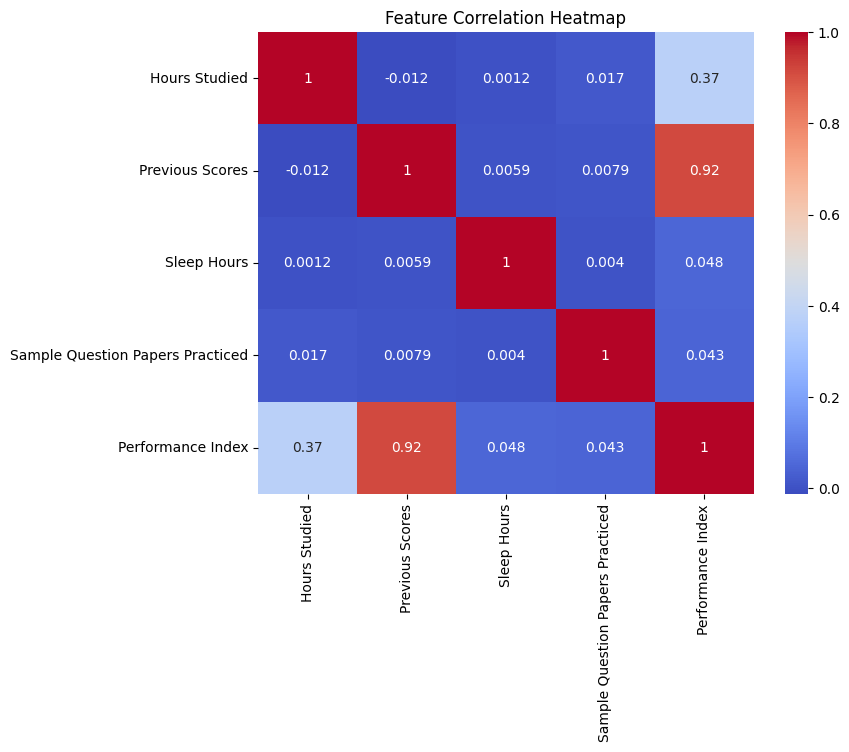

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [18]:
df["Extracurricular Activities"] = df["Extracurricular Activities"].map({"Yes":1, "No":0})

In [19]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


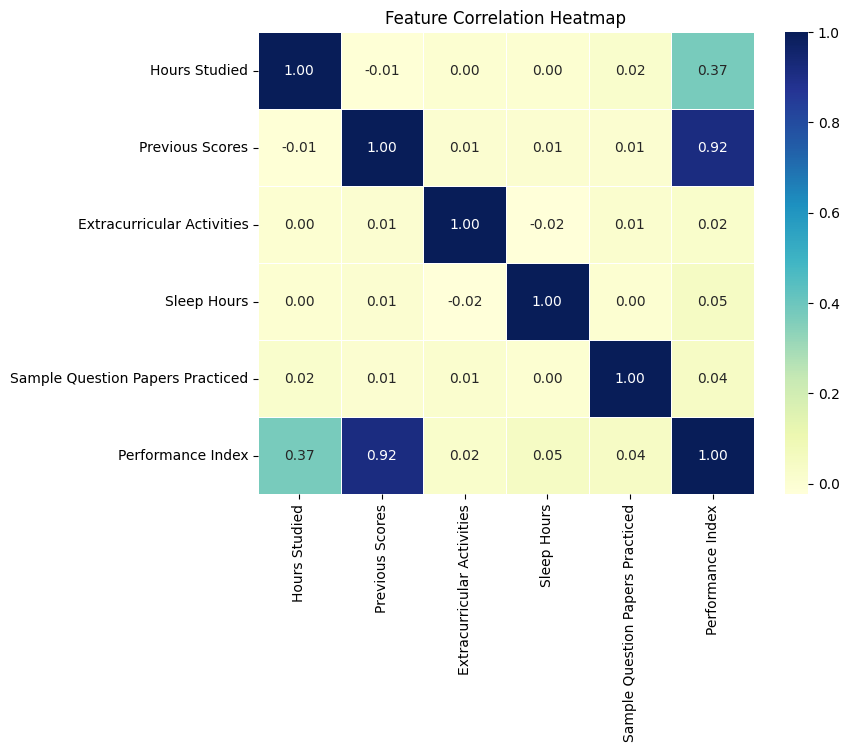

In [20]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap="YlGnBu",
            fmt=".2f",
            linewidths=0.5)

plt.title("Feature Correlation Heatmap")
plt.show()

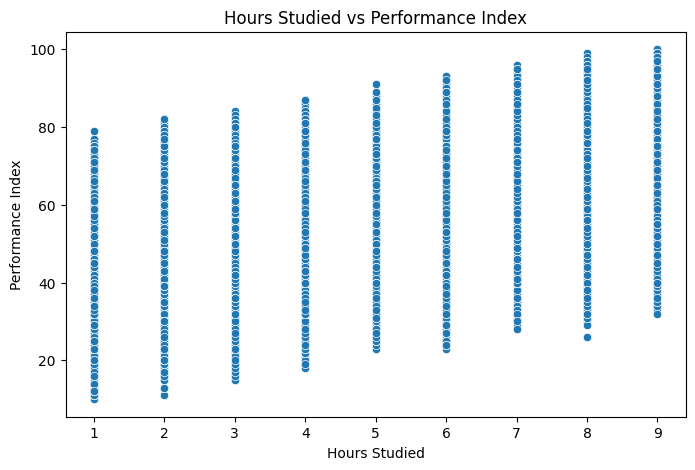

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Hours Studied'], y=df['Performance Index'])

plt.title("Hours Studied vs Performance Index")
plt.xlabel("Hours Studied")
plt.ylabel("Performance Index")
plt.show()

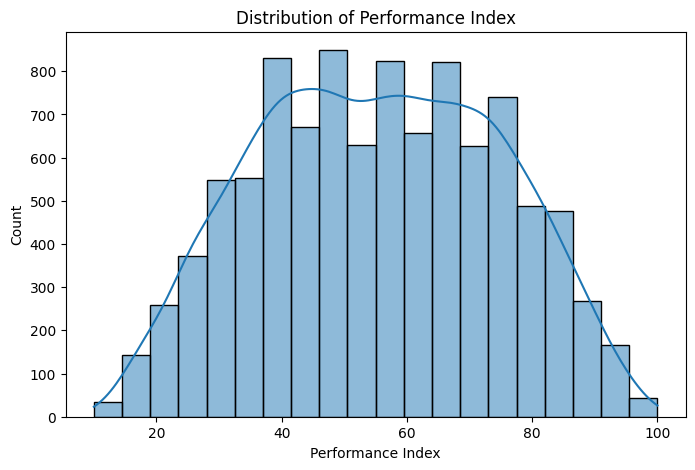

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(df['Performance Index'], bins=20, kde=True)

plt.title("Distribution of Performance Index")
plt.xlabel("Performance Index")
plt.ylabel("Count")
plt.show()

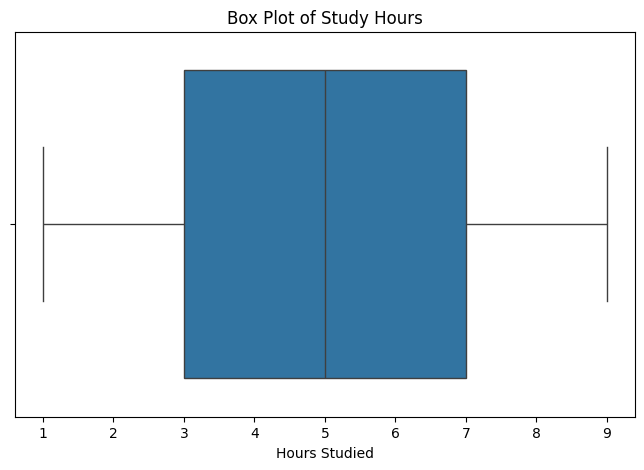

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Hours Studied'])

plt.title("Box Plot of Study Hours")
plt.show()

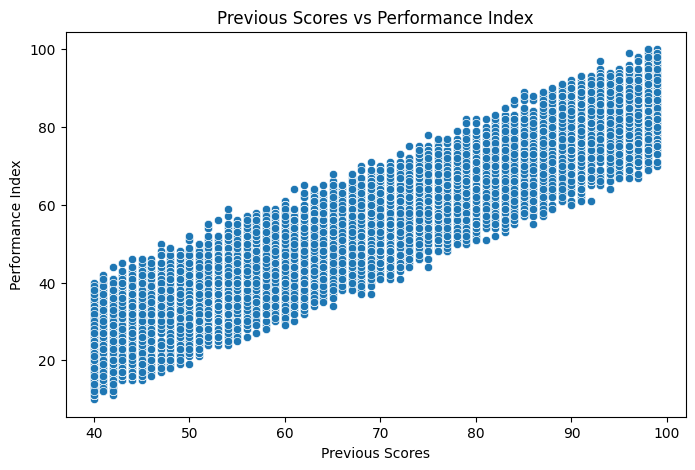

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Previous Scores'], y=df['Performance Index'])

plt.title("Previous Scores vs Performance Index")
plt.show()

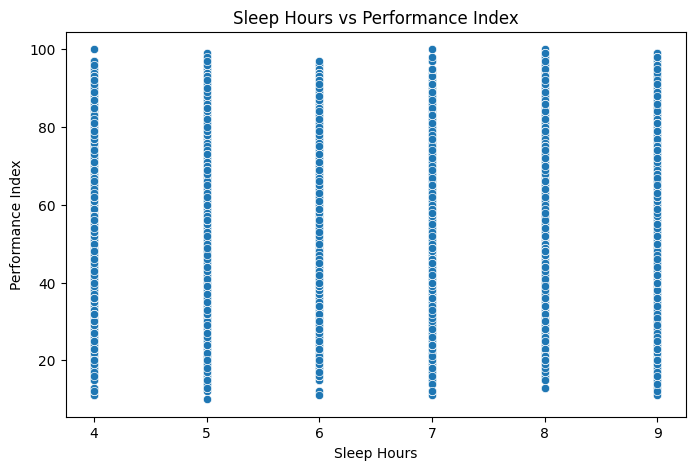

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Sleep Hours'], y=df['Performance Index'])

plt.title("Sleep Hours vs Performance Index")
plt.show()

In [26]:
X = df.drop("Performance Index", axis=1)
y = df["Performance Index"]

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,   # 30% testing
    random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

In [29]:
model = LinearRegression()

In [30]:
model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred = model.predict(X_test)

In [32]:
print(y_pred[:5])

[54.74728554 22.61884434 47.93665124 31.34009865 43.05974288]


In [33]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

comparison.head()

,Actual,Predicted
6252,51.0,54.747286
4684,20.0,22.618844
1731,46.0,47.936651
4742,28.0,31.340099
4521,41.0,43.059743


In [34]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 4.066563824092691
R2 Score: 0.9890110607021136


In [35]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression

model = LinearRegression()

scores = cross_val_score(model, X, y, cv=5, scoring="r2")

print("Cross Validation Scores:", scores)
print("Average R2 Score:", scores.mean())

Cross Validation Scores: [0.98879624 0.98827438 0.9891418  0.989087   0.98836991]
Average R2 Score: 0.9887338678935833


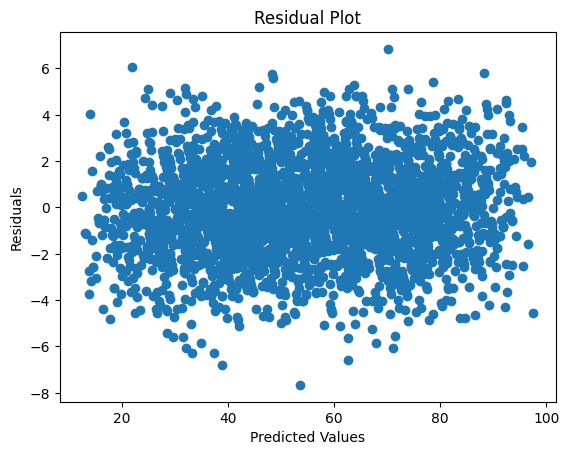

In [36]:
residuals = y_test - y_pred

import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [39]:
import pandas as pd

coeff = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coeff)

                                  Coefficient
Hours Studied                        2.858952
Previous Scores                      1.015520
Extracurricular Activities           0.581713
Sleep Hours                          0.479677
Sample Question Papers Practiced     0.190394


In [38]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

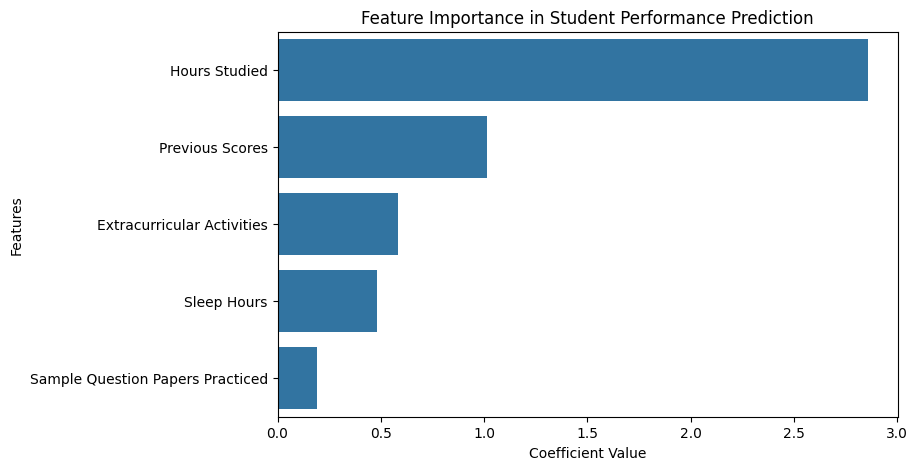

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

coeff = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])

plt.figure(figsize=(8,5))

sns.barplot(x=coeff["Coefficient"], y=coeff.index)

plt.title("Feature Importance in Student Performance Prediction")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")

plt.show()

In [41]:
import pickle

loaded_model = pickle.load(open("model/student_performance_model.pkl", "rb"))

print("Model loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'model/student_performance_model.pkl'

In [42]:
import pickle

loaded_model = pickle.load(open("studentperf/model/student_performance_model.pkl", "rb"))

print("Model loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'studentperf/model/student_performance_model.pkl'

In [1]:
import os
os.getcwd()

'c:\\Users\\Sanjana\\OneDrive\\Desktop\\studentperf\\notebooks'

In [4]:
os.listdir('model')

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'model'

In [5]:
import pickle

loaded_model = pickle.load(open(r"C:\Users\Sanjana\OneDrive\Desktop\studentperf\model\student_performance_model.pkl", "rb"))
print("Model loaded successfully")

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\Sanjana\\OneDrive\\Desktop\\studentperf\\model\\student_performance_model.pkl'

In [6]:
import os

# Change working directory to your project folder
os.chdir(r"C:\Users\Sanjana\OneDrive\Desktop\studentperf")

# Verify
print("Current working directory:", os.getcwd())

# List files in model folder
print(os.listdir("model"))

Current working directory: C:\Users\Sanjana\OneDrive\Desktop\studentperf
['std_perf.pkl']


In [11]:
import pickle

loaded_model = pickle.load(open("model/std_perf.pkl", "rb"))
print("Model loaded successfully")

# Test prediction
sample_input = [[5, 90, 80]]  # example feature values
print("Sample prediction:", loaded_model.predict(sample_input))

EOFError: Ran out of input

In [12]:
import os
os.path.getsize("model/std_perf.pkl")

0

In [13]:
import pickle
from sklearn.linear_model import LinearRegression

# Example: simple training
X_train = [[1, 2], [3, 4], [5, 6]]  # your feature values
y_train = [3, 7, 11]                # your target

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Save it properly
with open("model/std_perf.pkl", "wb") as f:  # note 'wb' mode
    pickle.dump(model, f)

print("Model saved successfully")

Model saved successfully


In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
import pickle

# Load the dataset
df = pd.read_csv("data/Student_Performance.csv")

# Encode 'Extracurricular Activities' into numbers (0 = No, 1 = Yes)
le = LabelEncoder()
df['Extracurricular Activities'] = le.fit_transform(df['Extracurricular Activities'])

# Features and target
X = df[['Hours Studied',
        'Previous Scores',
        'Extracurricular Activities',
        'Sleep Hours',
        'Sample Question Papers Practiced']]
y = df['Performance Index']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Save the model correctly
with open("model/std_perf.pkl", "wb") as f:
    pickle.dump(model, f)

print("Model trained and saved successfully!")

Model trained and saved successfully!


In [17]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0


In [18]:
import pickle

loaded_model = pickle.load(open("model/std_perf.pkl", "rb"))
print("Model loaded successfully!")

# example prediction
sample_input = [[6, 80, 1, 7, 5]]  # hours, previous score, yes(1), sleep, practice papers
print("Sample prediction:", loaded_model.predict(sample_input))

Model loaded successfully!
Sample prediction: [69.45837756]


c:\Users\Sanjana\OneDrive\Desktop\studentperf\venv\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
